In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau

import sys
sys.path.append('..')

from src.dataset import get_dataloaders
from src.models import get_model
from src.train import train

plt.rcParams['figure.dpi'] = 300

In [2]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'outputs', 'models')
FIGURES_DIR = os.path.join('..', 'outputs', 'figures')

if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
train_loader, val_loader, test_loader = get_dataloaders(PROCESSED_DIR)

train_normal = len(os.listdir(os.path.join(PROCESSED_DIR, 'train', 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(PROCESSED_DIR, 'train', 'PNEUMONIA')))
pos_weight = torch.tensor([train_normal / train_pneumonia], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Using device: cuda


In [4]:
model_resnet = get_model('resnet50').to(device)

optimiser_resnet = torch.optim.AdamW([
    {'params': model_resnet.layer3.parameters(), 'lr': 1e-4},
    {'params': model_resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': model_resnet.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_resnet = ReduceLROnPlateau(optimiser_resnet, mode='min', factor=0.1, patience=3)

history_resnet = train(
    model = model_resnet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_resnet, 
    scheduler = scheduler_resnet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(MODELS_DIR, 'resnet_50.pth')
)

Trainable: 22,065,153 / 23,510,081
Epoch 1/25 | Train Loss: 0.1213 | Val Loss: 0.0500
Epoch 2/25 | Train Loss: 0.0580 | Val Loss: 0.0618
Epoch 3/25 | Train Loss: 0.0456 | Val Loss: 0.0313
Epoch 4/25 | Train Loss: 0.0364 | Val Loss: 0.0370
Epoch 5/25 | Train Loss: 0.0337 | Val Loss: 0.0391
Epoch 6/25 | Train Loss: 0.0314 | Val Loss: 0.0351
Epoch 7/25 | Train Loss: 0.0247 | Val Loss: 0.0500
Epoch 8/25 | Train Loss: 0.0140 | Val Loss: 0.0335
Epoch 9/25 | Train Loss: 0.0115 | Val Loss: 0.0336
Epoch 10/25 | Train Loss: 0.0139 | Val Loss: 0.0319
Early stopping at epoch 10


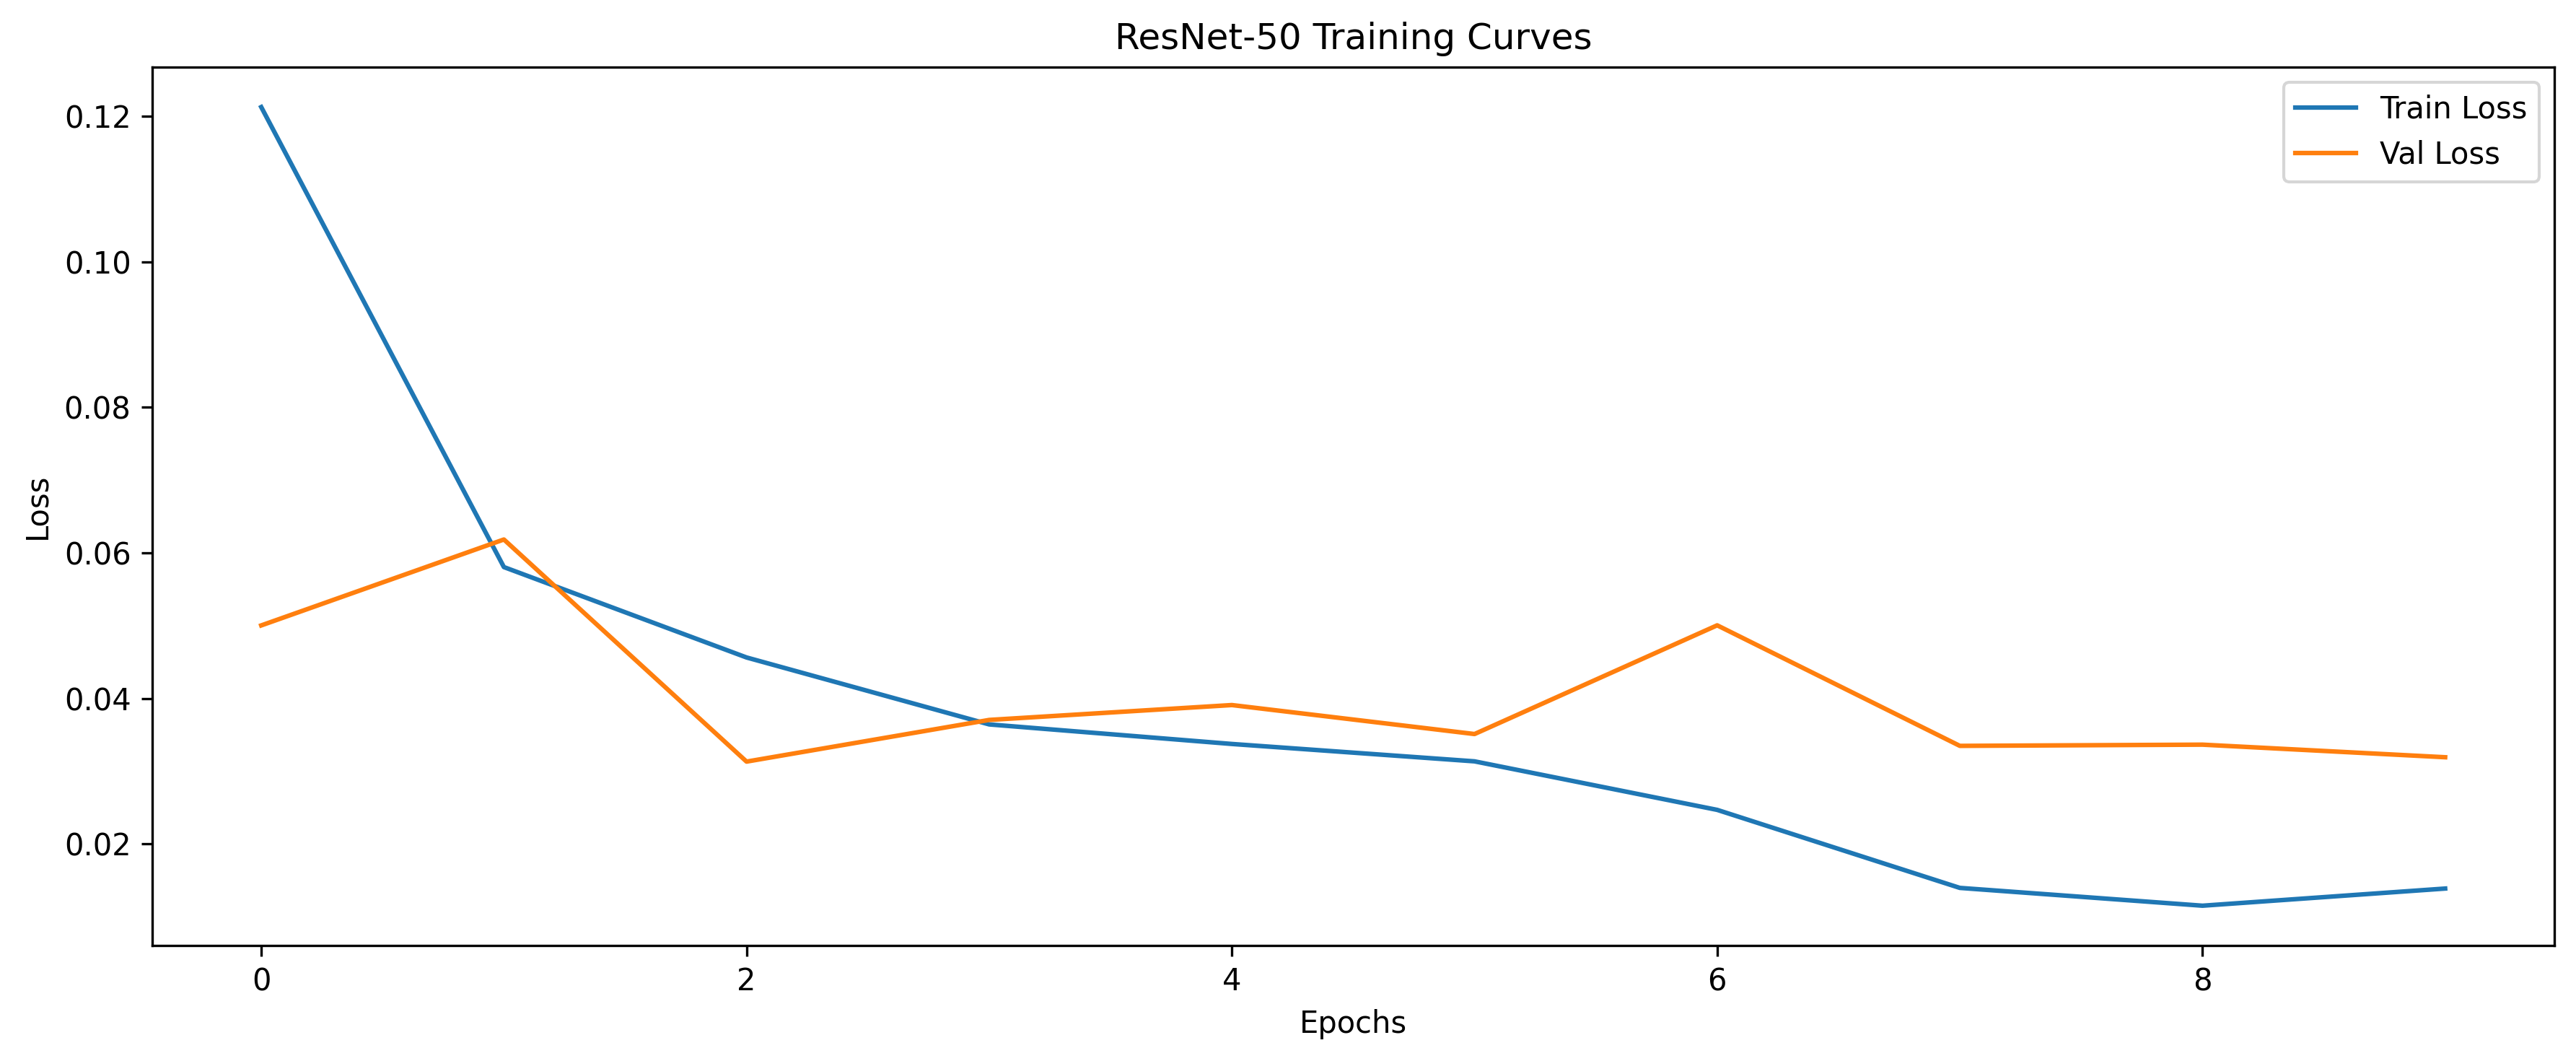

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['train_loss'], label='Train Loss')
plt.plot(history_resnet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-50 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_resnet_50_training_curves.png'))
plt.show()

In [6]:
del model_resnet
torch.cuda.empty_cache()

In [7]:
model_densenet = get_model('densenet121').to(device)

optimiser_densenet = torch.optim.AdamW([
    {'params': model_densenet.features.denseblock3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.transition3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.norm5.parameters(), 'lr': 1e-4},
    {'params': model_densenet.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_densenet = ReduceLROnPlateau(optimiser_densenet, mode='min', factor=0.1, patience=3)

history_densenet = train(
    model = model_densenet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_densenet, 
    scheduler = scheduler_densenet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(MODELS_DIR, 'densenet_121.pth')
)

Trainable: 5,525,249 / 6,954,881
Epoch 1/25 | Train Loss: 0.1056 | Val Loss: 0.0554
Epoch 2/25 | Train Loss: 0.0524 | Val Loss: 0.0319
Epoch 3/25 | Train Loss: 0.0396 | Val Loss: 0.0363
Epoch 4/25 | Train Loss: 0.0367 | Val Loss: 0.0386
Epoch 5/25 | Train Loss: 0.0241 | Val Loss: 0.0330
Epoch 6/25 | Train Loss: 0.0244 | Val Loss: 0.0551
Epoch 7/25 | Train Loss: 0.0151 | Val Loss: 0.0304
Epoch 8/25 | Train Loss: 0.0113 | Val Loss: 0.0340
Epoch 9/25 | Train Loss: 0.0106 | Val Loss: 0.0300
Epoch 10/25 | Train Loss: 0.0092 | Val Loss: 0.0302
Epoch 11/25 | Train Loss: 0.0088 | Val Loss: 0.0312
Epoch 12/25 | Train Loss: 0.0105 | Val Loss: 0.0375
Epoch 13/25 | Train Loss: 0.0108 | Val Loss: 0.0334
Epoch 14/25 | Train Loss: 0.0055 | Val Loss: 0.0308
Epoch 15/25 | Train Loss: 0.0065 | Val Loss: 0.0314
Epoch 16/25 | Train Loss: 0.0057 | Val Loss: 0.0293
Epoch 17/25 | Train Loss: 0.0063 | Val Loss: 0.0308
Epoch 18/25 | Train Loss: 0.0057 | Val Loss: 0.0316
Epoch 19/25 | Train Loss: 0.0087 | Val L

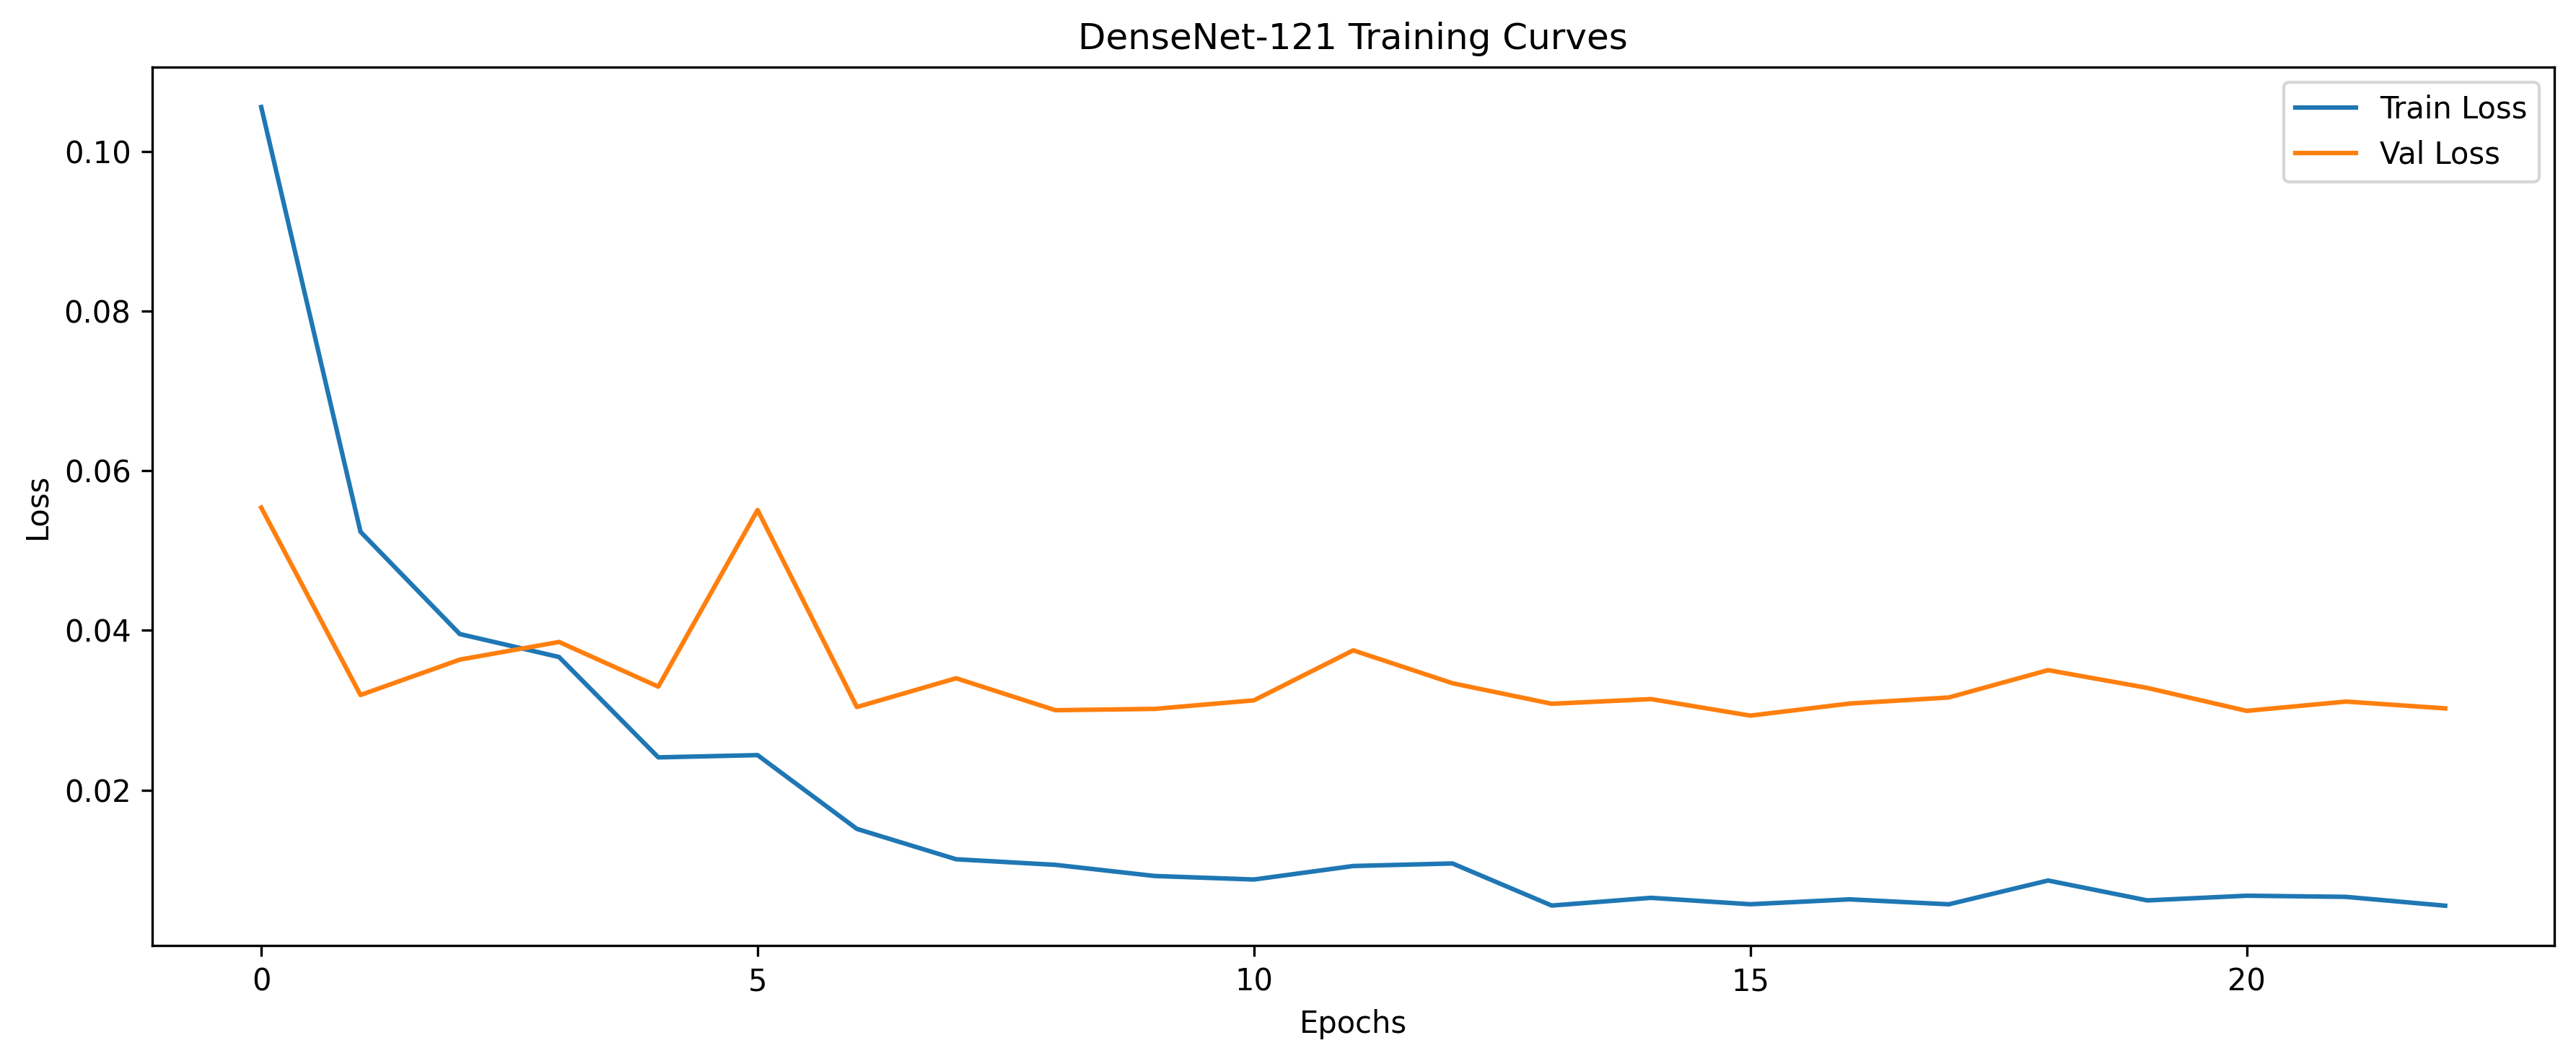

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(history_densenet['train_loss'], label='Train Loss')
plt.plot(history_densenet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet-121 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_densenet_121_training_curves.png'))
plt.show()

In [9]:
del model_densenet
torch.cuda.empty_cache()

In [10]:
model_efficientnet = get_model('efficientnet_b0').to(device)

optimiser_efficientnet = torch.optim.AdamW([
    {'params': model_efficientnet.features[5].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[6].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[7].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[8].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_efficientnet = ReduceLROnPlateau(optimiser_efficientnet, mode='min', factor=0.1, patience=3)

history_efficientnet = train(
    model = model_efficientnet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_efficientnet, 
    scheduler = scheduler_efficientnet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(MODELS_DIR, 'efficientnet_b0.pth')
)

Trainable: 3,700,169 / 4,008,829
Epoch 1/25 | Train Loss: 0.1246 | Val Loss: 0.0818
Epoch 2/25 | Train Loss: 0.0695 | Val Loss: 0.0506
Epoch 3/25 | Train Loss: 0.0581 | Val Loss: 0.0419
Epoch 4/25 | Train Loss: 0.0498 | Val Loss: 0.0494
Epoch 5/25 | Train Loss: 0.0392 | Val Loss: 0.0589
Epoch 6/25 | Train Loss: 0.0428 | Val Loss: 0.0340
Epoch 7/25 | Train Loss: 0.0310 | Val Loss: 0.0410
Epoch 8/25 | Train Loss: 0.0297 | Val Loss: 0.0402
Epoch 9/25 | Train Loss: 0.0310 | Val Loss: 0.0326
Epoch 10/25 | Train Loss: 0.0229 | Val Loss: 0.0322
Epoch 11/25 | Train Loss: 0.0310 | Val Loss: 0.0443
Epoch 12/25 | Train Loss: 0.0239 | Val Loss: 0.0578
Epoch 13/25 | Train Loss: 0.0191 | Val Loss: 0.0391
Epoch 14/25 | Train Loss: 0.0149 | Val Loss: 0.0465
Epoch 15/25 | Train Loss: 0.0141 | Val Loss: 0.0369
Epoch 16/25 | Train Loss: 0.0114 | Val Loss: 0.0413
Epoch 17/25 | Train Loss: 0.0116 | Val Loss: 0.0369
Early stopping at epoch 17


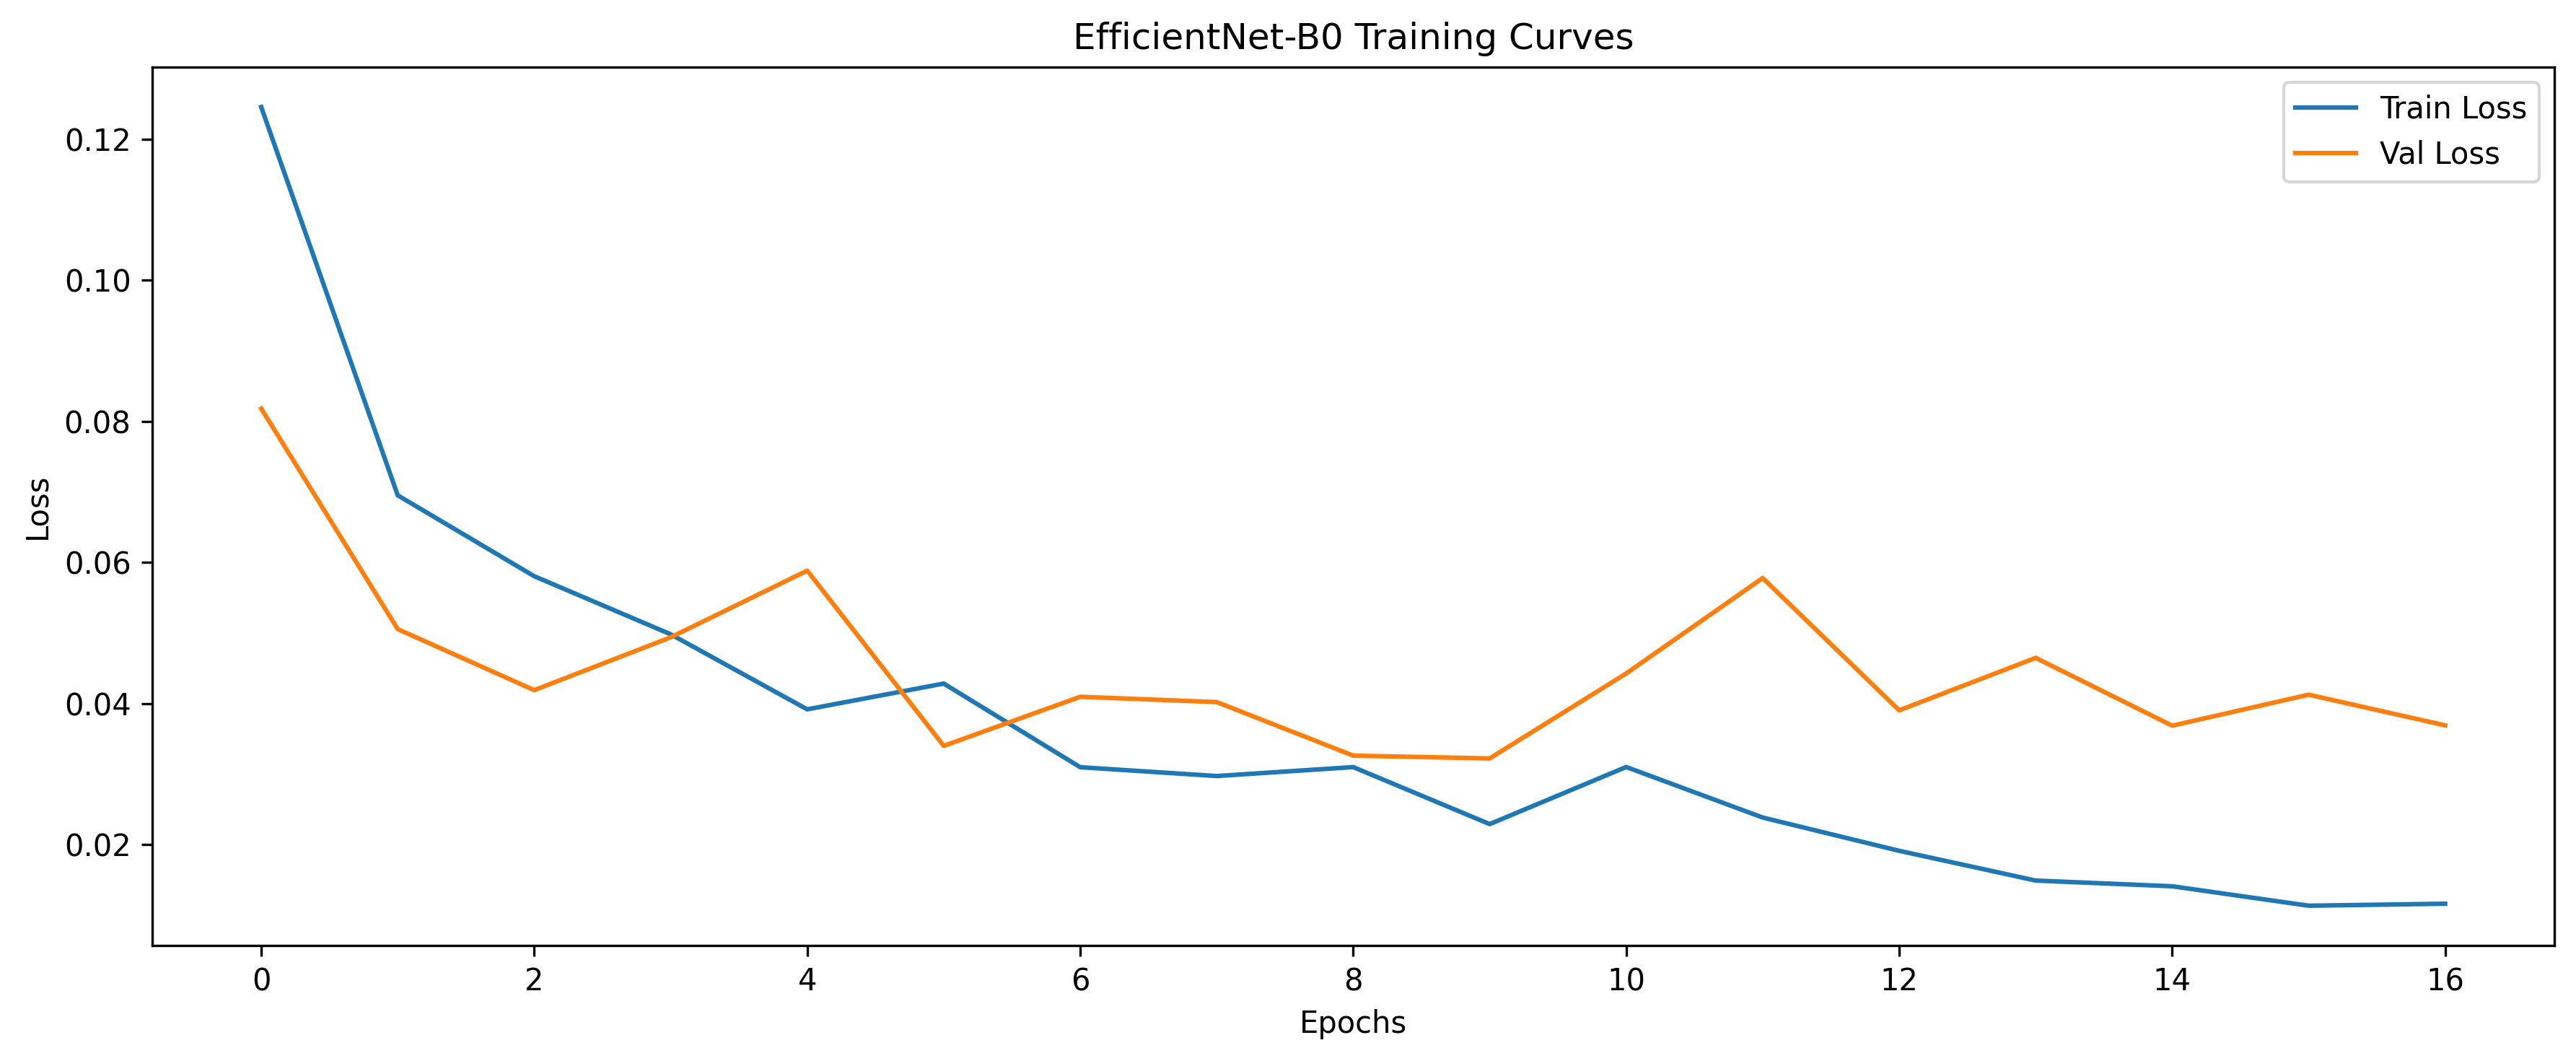

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(history_efficientnet['train_loss'], label='Train Loss')
plt.plot(history_efficientnet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNet-B0 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_efficientnet_b0_training_curves.png'))
plt.show()

In [12]:
del model_efficientnet
torch.cuda.empty_cache()

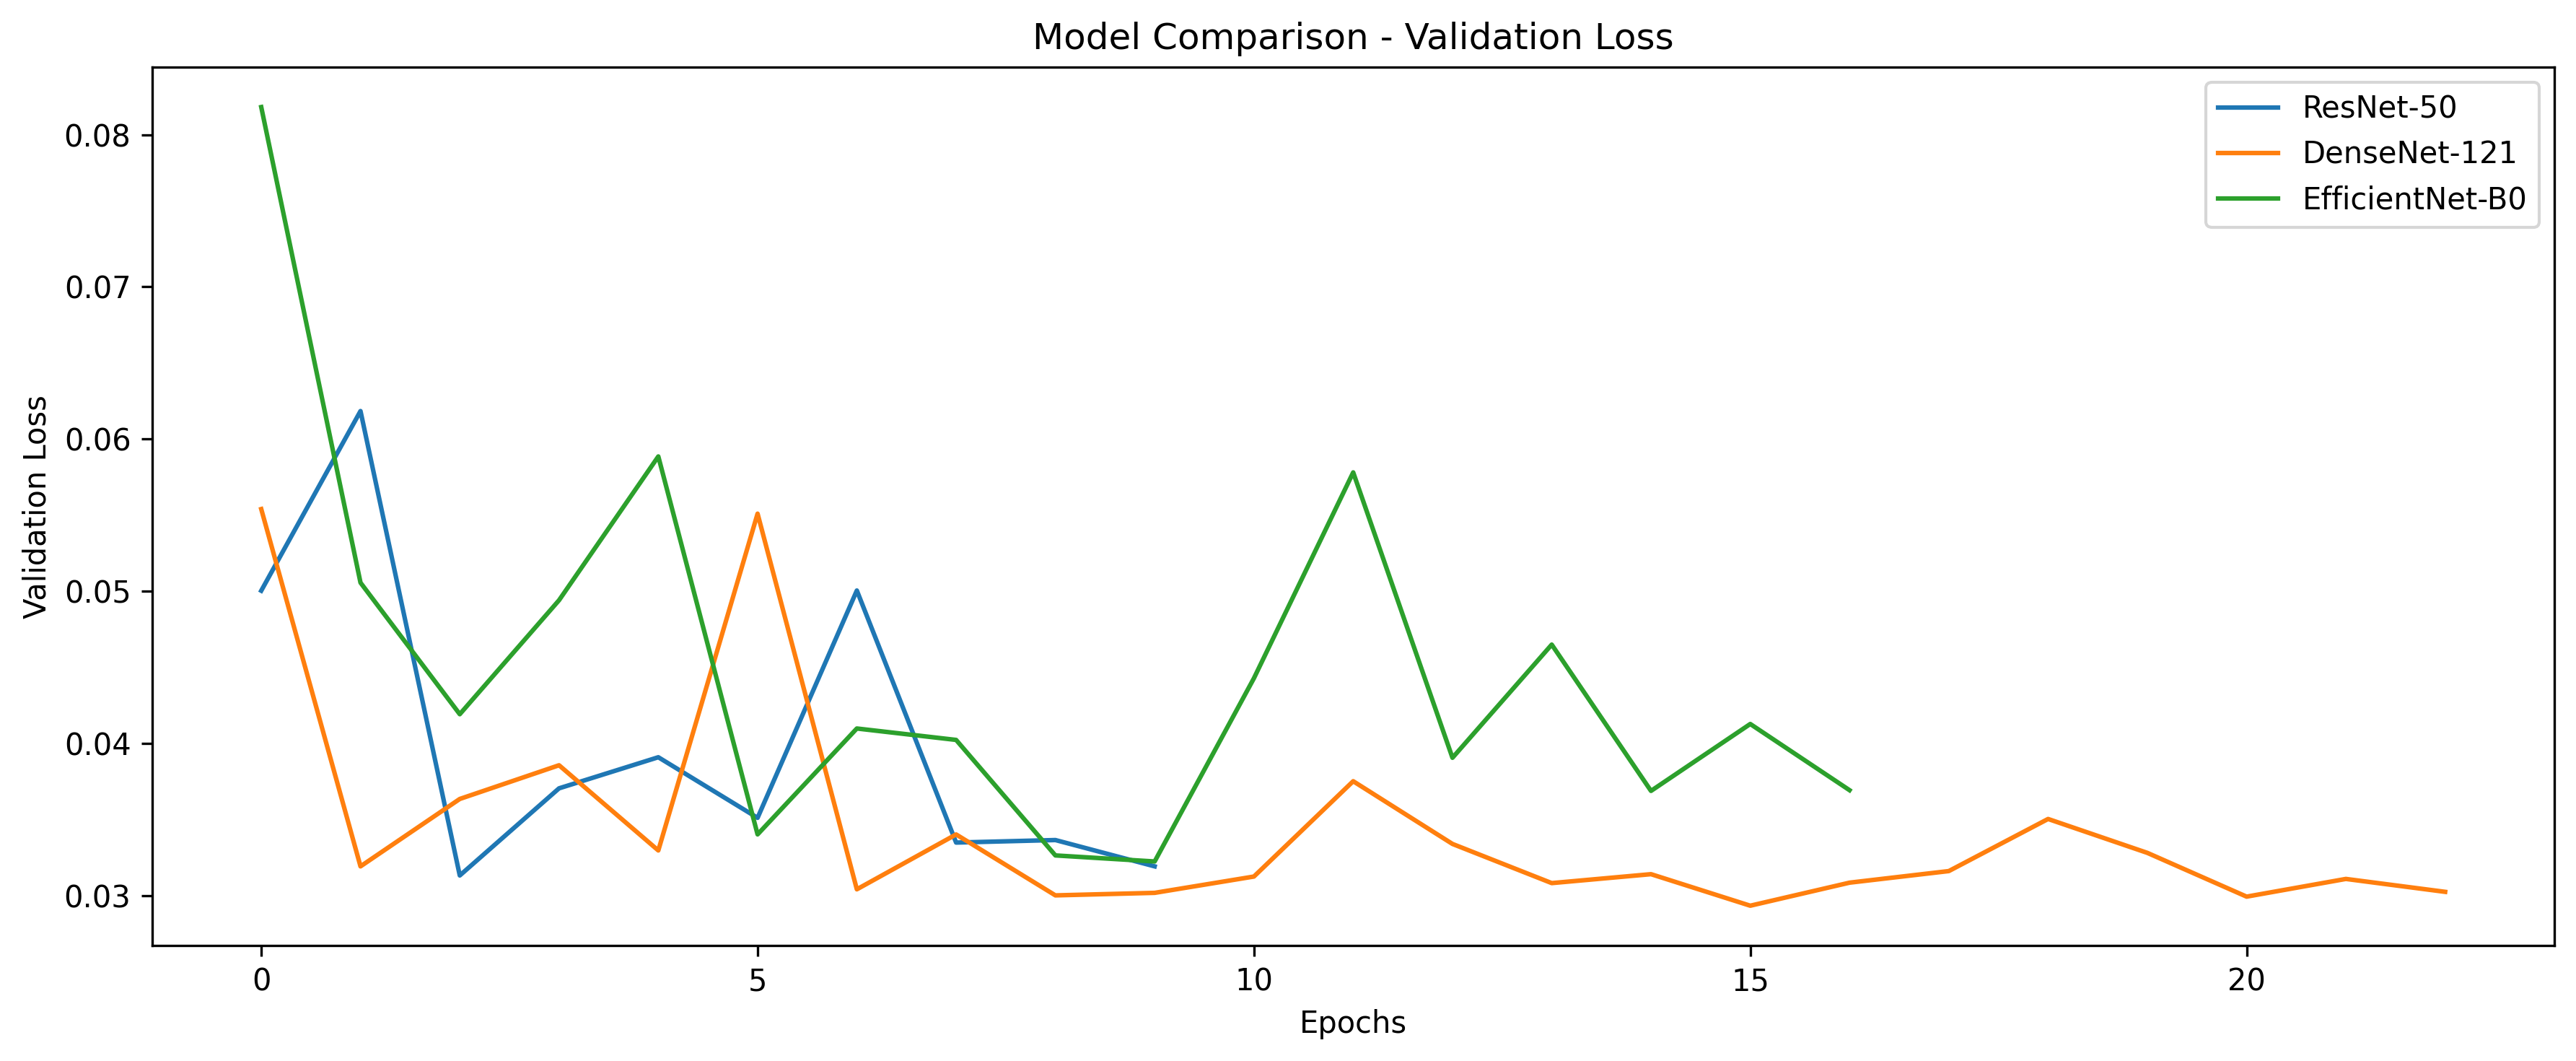

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['val_loss'], label='ResNet-50')
plt.plot(history_densenet['val_loss'], label='DenseNet-121')
plt.plot(history_efficientnet['val_loss'], label='EfficientNet-B0')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Model Comparison - Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig6_model_comparison.png'))
plt.show()